# Comparing Projections

This notebook tries to assess the differences between the SVM on the PyRiemann tangent space projection os the EEG covariance matrices and the SPDNet (also EEGSPDNet) on the THINGS-EEG.

We observed that the (EEG)SPDNet are performing worse than the SVM approach, what is not expected since there is a training pipeline on the SPD manifold and the FC layer should at least similar to the SVM after the projections.

We have some hypotesis on why this is happening and I will address one of them in this notebook.

The hypotesis are:
- The SPDNet implemented on SPD Learn seems to use a regular Addam to optimize BiMap layers, using a orthogonalization operation to keep the lines of the weight matrices on the Stiefel manifold. This imposes a stronger constraint on the W structure than what is required on SPDNet formualtion. This may act as a regularization, but my guess is that it avoids important places of the search space.
- The SPDNet has a geometric problem in its LogEig layer. The common pipeline to project the SPD matrices to a Euclidian tangent space is to estimate a mean SPD matrix to act as the tangent point and then project them in reference to this one. Although, the LogEig projects all matrices in relation to the identity matrix, whay is, most surely, causing difficulties on the local geometry.

The second point is what I want to assess.

Now, I will fit a tangent space on the same dataset (w/ xDawn and LWF estimation) as the (EEG)SPDNet and calculate their Frechet Mean to see how distant hey are from the Identity matrix, as well as the mean distances between the matrices (Frechet of the difference).

In [1]:
# Lib
import sys
sys.path.append("/home/rffl/files/ic/utils/")

import torch
import datagen, eegdataset #type: ignore
from spd_learn.models import EEGSPDNet
from torch.utils.data import DataLoader
from torchmetrics.classification import ConfusionMatrix
import matplotlib.pyplot as plt
import numpy as np
import pyriemann as rmn
import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

metric = "riemann"
estimator = "lwf"

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
# Data config
classVec = [i+1 for i in range(10)]
subVec = [i+1 for i in range(10)]

nClass = len(classVec)
nSub = len(subVec)

## Tangent Space w/ Frechet Mean

In [3]:
# Data gen
train_path, test_path = datagen.generatedataset(classVec, subVec, 0.75, False)

Saved ./train.npy shape = (6000, 17, 100)
Saved ./test.npy shape = (2000, 17, 100)


In [4]:
# xDAWN treatment
import pyriemann as rmn
xDAWNfilters = 10
estimator = "lwf"

X_train = np.load(train_path, allow_pickle=True)
X_test = np.load(test_path, allow_pickle=True)

y_train = np.array([])
part = len(X_train) // len(classVec)
for i in range(len(classVec)):
    y_train = np.concatenate([y_train, i * np.ones(part)])

cov = rmn.estimation.XdawnCovariances(nfilter=xDAWNfilters, estimator=estimator)
X_train_cov = cov.fit_transform(X_train, y_train)
X_test_cov = cov.transform(X_test)

np.save(train_path, X_train )
np.save(test_path, X_test )

In [7]:
# Tangent Space
tangSpace = rmn.tangentspace.TangentSpace(metric=metric)
X_tang_train = tangSpace.fit_transform(X_train_cov)
X_tang_test = tangSpace.transform(X_test_cov)

In [17]:
i = -1
sum = 0
for trial in X_tang_train:
    i += 1
    norm = np.linalg.norm(trial, ord=2)
    sum += norm
    if(i%100 == 0):
        print(f"Norm of {i}-esim trial: {norm}")
print(f"Mean norm: {sum/X_tang_train.shape[0]}")


Norm of 0-esim trial: 7.036235589595285
Norm of 100-esim trial: 5.353682830080452
Norm of 200-esim trial: 9.258254782114193
Norm of 300-esim trial: 5.429775506941936
Norm of 400-esim trial: 6.782612631512938
Norm of 500-esim trial: 6.741775490128157
Norm of 600-esim trial: 6.249825319964323
Norm of 700-esim trial: 7.081759865861627
Norm of 800-esim trial: 8.37591234267001
Norm of 900-esim trial: 4.949006501753471
Norm of 1000-esim trial: 6.776254105568233
Norm of 1100-esim trial: 6.761286745438352
Norm of 1200-esim trial: 6.320071073760784
Norm of 1300-esim trial: 6.5346047570919765
Norm of 1400-esim trial: 8.323257228357846
Norm of 1500-esim trial: 7.70452311442264
Norm of 1600-esim trial: 6.0542684441318055
Norm of 1700-esim trial: 7.381459728486632
Norm of 1800-esim trial: 6.391910800926708
Norm of 1900-esim trial: 4.85458711995764
Norm of 2000-esim trial: 8.45385022919044
Norm of 2100-esim trial: 4.820745182304317
Norm of 2200-esim trial: 5.860757877374311
Norm of 2300-esim trial: 

In [23]:
i = -1
sum = 0
for trial in X_tang_test:
    i += 1
    norm = np.linalg.norm(trial, ord=2)
    sum += norm
    if(i%100 == 0):
        print(f"Norm of {i}-esim trial: {norm}")
print(f"Mean norm: {sum/X_tang_test.shape[0]}")


Norm of 0-esim trial: 8.707445837202677
Norm of 100-esim trial: 5.96126410701921
Norm of 200-esim trial: 9.56927020185282
Norm of 300-esim trial: 4.9041437558377154
Norm of 400-esim trial: 8.709606544202005
Norm of 500-esim trial: 5.221902300751196
Norm of 600-esim trial: 8.552028344106443
Norm of 700-esim trial: 5.226620007916419
Norm of 800-esim trial: 7.685647869661057
Norm of 900-esim trial: 5.627224231735994
Norm of 1000-esim trial: 9.32255424724398
Norm of 1100-esim trial: 5.609006658182476
Norm of 1200-esim trial: 15.331477797709745
Norm of 1300-esim trial: 5.651105937023317
Norm of 1400-esim trial: 8.324205125106925
Norm of 1500-esim trial: 5.7070229728102895
Norm of 1600-esim trial: 7.8523511362799825
Norm of 1700-esim trial: 4.980621441731702
Norm of 1800-esim trial: 7.553671438309028
Norm of 1900-esim trial: 4.904108144523774
Mean norm: 7.395441193859081


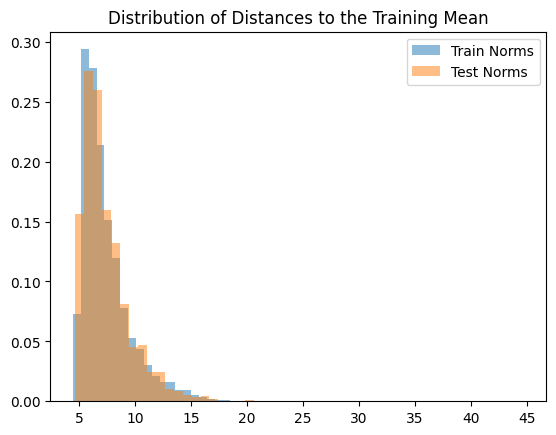

In [ ]:
train_norms = np.linalg.norm(X_tang_train, axis=1, ord=2)
test_norms = np.linalg.norm(X_tang_test, axis=1, ord=2)

plt.hist(train_norms, bins=50, alpha=0.5, label='Train Norms', density=True)
plt.hist(test_norms, bins=50, alpha=0.5, label='Test Norms', density=True)
plt.legend()
plt.title("Distribution of Distances to the Training Mean")
plt.show()

## LogEig projection

In [3]:
# Data gen
train_path, test_path = datagen.generatedataset(classVec, subVec, 0.75, False)

Saved ./train.npy shape = (6000, 17, 100)
Saved ./test.npy shape = (2000, 17, 100)


In [4]:
# xDAWN treatment
import pyriemann as rmn
xDAWNfilters = 5
estimator = "lwf"

X_train = np.load(train_path, allow_pickle=True)
X_test = np.load(test_path, allow_pickle=True)

y_train = np.array([])
part = len(X_train) // len(classVec)
for i in range(len(classVec)):
    y_train = np.concatenate([y_train, i * np.ones(part)])

xdawn = rmn.estimation.Xdawn(nfilter=xDAWNfilters, estimator=estimator)
xdawn.fit(X_train, y_train)

X_train = np.einsum('fc,nct->nft', xdawn.filters_, X_train)
X_test  = np.einsum('fc,nct->nft', xdawn.filters_, X_test)

np.save(train_path, X_train )
np.save(test_path, X_test )

In [5]:
# Dataset and Dataloader init
trainDataset = eegdataset.KClassDataset(nClass, "./train.npy")
trainLoader = DataLoader(trainDataset, 40, True, num_workers=4)

testDataset = eegdataset.KClassDataset(nClass, "./test.npy")
testLoader = DataLoader(testDataset, 40, True, num_workers=4)

### Auxiliary functions

In [6]:
# Auxiliary functions
import time
def regular_train(model, classVec, trainLoader, testLoader, epochs, device):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_hist_loss = []
    test_hist_loss = []

    train_hist_acc = []
    test_hist_acc = []

    begin = time.time()
    print(f"Begin {begin}")
    for epoch in range(epochs):
        train_loss, train_acc = train(model, trainLoader, criterion, optimizer, device)
        test_loss, test_acc = test(model, testLoader, criterion, device)
        train_hist_loss.append(train_loss); train_hist_acc.append(train_acc)
        test_hist_loss.append(test_loss); test_hist_acc.append(test_acc)
        print(f"Epoch {epoch+1}: "
        f"Train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"Test loss {test_loss:.4f}, acc {test_acc:.4f} | "
        f"Time {time.time() - begin} s")

    confmat = ConfusionMatrix(task="multiclass", num_classes=len(classVec))    

    fig, axs = plt.subplots(1,2)
    axs[0].plot(range(epochs), train_hist_loss, label="Train Loss")
    axs[0].plot(range(epochs), test_hist_loss, label="Test Loss")
    axs[0].legend()

    axs[1].plot(range(epochs), train_hist_acc, label="Train Accuracy")
    axs[1].plot(range(epochs), test_hist_acc, label="Test Accuracy")
    axs[1].legend()
    fig.show()

    for X, y in testLoader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        preds = torch.argmax(logits, dim=1)

        confmat.update(preds.cpu(), y.cpu())

    confmatrix = confmat.compute()
    plot_confusion_matrix(confmatrix, classVec)

def train(model, trainLoader, criterion, optimizer, device):
    torch.cuda.empty_cache()
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X, y in trainLoader:
        X = X.to(device); y = y.to(device)

        optimizer.zero_grad()
        y_hat = model(X)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    
    avg_loss = total_loss / len(trainLoader)
    acc = correct / total
    return avg_loss, acc

@torch.no_grad()
def test(model, testLoader, criterion, device):
    torch.cuda.empty_cache()
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    for X, y in testLoader:
        X = X.to(device); y = y.to(device)

        y_hat = model(X)
        total_loss += criterion(y_hat, y).item()

        pred = y_hat.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    
    avg_loss = total_loss / len(testLoader)
    acc = correct / total
    return avg_loss, acc

def plot_confusion_matrix(confmatrix, class_names=None):
    plt.figure(figsize=(6, 5))
    plt.imshow(confmatrix, interpolation='nearest')
    plt.title("Confusion Matrix")
    plt.colorbar()

    num_classes = confmatrix.shape[0]

    # Tick labels
    if not class_names:
        class_names = [str(i) for i in range(num_classes)]

    plt.xticks(range(num_classes), class_names, rotation=45)
    plt.yticks(range(num_classes), class_names)

    # Print values inside cells
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, str(confmatrix[i, j].item()),
                     ha="center", va="center", color="white" if confmatrix[i, j] > confmatrix.max()/2 else "black")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

### Training and Mapping

In [7]:
from spd_learn.modules import Shrinkage

class EEGSPDNetLWF(EEGSPDNet):
    def __init__(self, *args, initShrinkage=0.0, **kwargs):
        super().__init__(*args, **kwargs)
        n_cov = self.n_chans * self.n_filters
        self.shrinkage = Shrinkage(n_chans=n_cov, init_shrinkage=initShrinkage, learnable=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.cov_pool(x)
        x = self.shrinkage(x)
        x = self.spdnet(x)
        x = self.dropout(x)
        x = self.linear(x)
        return x

Begin 1781712622.999351
Epoch 1: Train loss 2.4440, acc 0.1193 | Test loss 2.1567, acc 0.2235 | Time 293.1369106769562 s
Epoch 2: Train loss 2.3155, acc 0.1687 | Test loss 1.9988, acc 0.3000 | Time 588.995171546936 s
Epoch 3: Train loss 2.2485, acc 0.1970 | Test loss 2.0440, acc 0.2960 | Time 870.7495014667511 s
Epoch 4: Train loss 2.1733, acc 0.2330 | Test loss 2.0569, acc 0.3135 | Time 1171.8407607078552 s
Epoch 5: Train loss 2.1190, acc 0.2600 | Test loss 2.0689, acc 0.3205 | Time 1470.2881586551666 s
Epoch 6: Train loss 2.0854, acc 0.2692 | Test loss 2.1982, acc 0.3200 | Time 1771.928326845169 s
Epoch 7: Train loss 2.0379, acc 0.2910 | Test loss 2.1024, acc 0.3415 | Time 2072.5522480010986 s
Epoch 8: Train loss 2.0138, acc 0.3050 | Test loss 2.2539, acc 0.3325 | Time 2373.017730474472 s
Epoch 9: Train loss 2.0028, acc 0.3182 | Test loss 2.2180, acc 0.3410 | Time 2677.4787418842316 s
Epoch 10: Train loss 1.9761, acc 0.3218 | Test loss 2.2504, acc 0.3520 | Time 2975.1027812957764 s
E

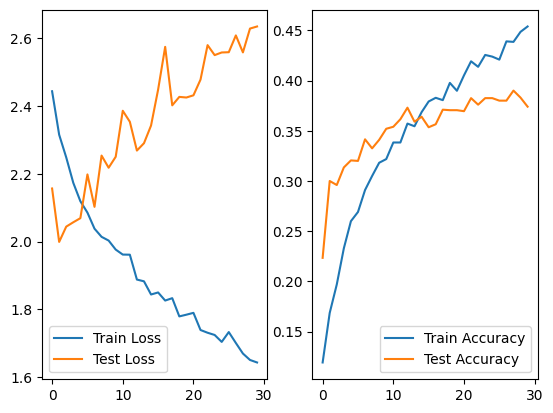

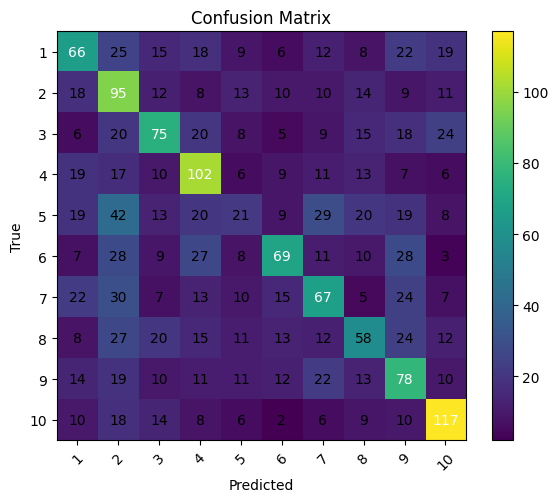

In [9]:
model = EEGSPDNetLWF(50, 10, n_filters=10, bimap_sizes=(2, 1), filter_time_length = 50, final_layer_drop_prob=0.5, spd_drop_prob=0.25).to(device)
regular_train(model, classVec, trainLoader, testLoader, 30, device)

In [10]:
# Forward hook
model.eval()

extract = []

def get_map():
    def logeigHook(model, input, output):
            extract.append(output.detach().cpu().numpy())
    return logeigHook

hook = model.spdnet.register_forward_hook(get_map())


In [11]:
# Train distances

extract = []
trainLoaderMap = DataLoader(trainDataset, batch_size=64, shuffle=False)
with torch.no_grad():
    for batch in trainLoaderMap:
        X = batch[0].to(device)
        y = model(X)

extract_train = np.concatenate(extract[:], axis=0)

In [12]:
i = -1
sum = 0
for trial in extract_train:
    i += 1
    norm = np.linalg.norm(trial, ord=2)
    sum += norm
    if(i%100 == 0):
        print(f"Norm of {i}-esim trial: {norm}")
print(f"Mean norm: {sum/len(extract_train)}")


Norm of 0-esim trial: 35.90568542480469
Norm of 100-esim trial: 43.09377670288086
Norm of 200-esim trial: 37.96067810058594
Norm of 300-esim trial: 38.26133728027344
Norm of 400-esim trial: 35.371036529541016
Norm of 500-esim trial: 37.17329025268555
Norm of 600-esim trial: 38.13045120239258
Norm of 700-esim trial: 41.61470413208008
Norm of 800-esim trial: 37.83602523803711
Norm of 900-esim trial: 39.12989807128906
Norm of 1000-esim trial: 34.83603286743164
Norm of 1100-esim trial: 34.39751434326172
Norm of 1200-esim trial: 36.365577697753906
Norm of 1300-esim trial: 46.91044616699219
Norm of 1400-esim trial: 38.443077087402344
Norm of 1500-esim trial: 35.94001007080078
Norm of 1600-esim trial: 35.77481460571289
Norm of 1700-esim trial: 38.4787483215332
Norm of 1800-esim trial: 36.229393005371094
Norm of 1900-esim trial: 40.70539093017578
Norm of 2000-esim trial: 37.25005340576172
Norm of 2100-esim trial: 39.01040267944336
Norm of 2200-esim trial: 33.59873962402344
Norm of 2300-esim tr

In [13]:
# Test distances

extract = []
testLoaderMap = DataLoader(testDataset, batch_size=64, shuffle=False)
with torch.no_grad():
    for batch in testLoaderMap:
        X = batch[0].to(device)
        y = model(X)

extract_test = np.concatenate(extract[:], axis=0)

In [14]:
i = -1
sum = 0
for trial in extract_test:
    i += 1
    norm = np.linalg.norm(trial, ord=2)
    sum += norm
    if(i%100 == 0):
        print(f"Norm of {i}-esim trial: {norm}")
print(f"Mean norm: {sum/len(extract_test)}")


Norm of 0-esim trial: 33.701255798339844
Norm of 100-esim trial: 35.479469299316406
Norm of 200-esim trial: 39.565242767333984
Norm of 300-esim trial: 38.41798782348633
Norm of 400-esim trial: 41.47649383544922
Norm of 500-esim trial: 35.751399993896484
Norm of 600-esim trial: 36.036067962646484
Norm of 700-esim trial: 34.9555778503418
Norm of 800-esim trial: 39.91452407836914
Norm of 900-esim trial: 34.23215103149414
Norm of 1000-esim trial: 40.873748779296875
Norm of 1100-esim trial: 33.718379974365234
Norm of 1200-esim trial: 43.049617767333984
Norm of 1300-esim trial: 36.75162124633789
Norm of 1400-esim trial: 37.89175033569336
Norm of 1500-esim trial: 34.60050964355469
Norm of 1600-esim trial: 39.330406188964844
Norm of 1700-esim trial: 37.15879821777344
Norm of 1800-esim trial: 40.0555419921875
Norm of 1900-esim trial: 37.148643493652344
Mean norm: 37.957689170837405


Mean train norm: 37.864498138427734
Standart deviation of train norm: 4.534381866455078
Mean test norm: 37.95769119262695
Standart deviation of train norm: 4.552596092224121


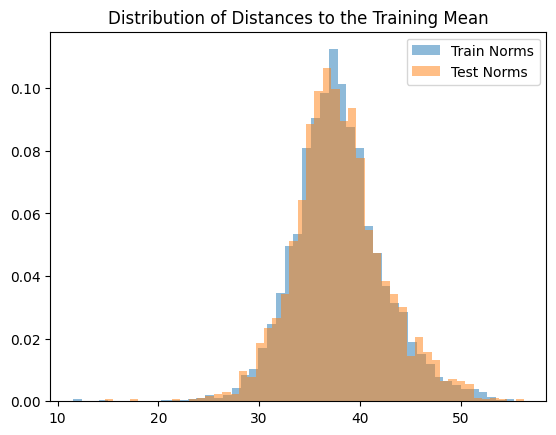

In [16]:
train_norms = np.linalg.norm(extract_train, axis=1, ord=2)
test_norms = np.linalg.norm(extract_test, axis=1, ord=2)

print(f"Mean train norm: {np.mean(train_norms)}")
print(f"Standart deviation of train norm: {np.std(train_norms)}")
print(f"Mean test norm: {np.mean(test_norms)}")
print(f"Standart deviation of train norm: {np.std(test_norms)}")
plt.hist(train_norms, bins=50, alpha=0.5, label='Train Norms', density=True)
plt.hist(test_norms, bins=50, alpha=0.5, label='Test Norms', density=True)
plt.legend()
plt.title("Distribution of Distances to the Training Mean")
plt.show()

# Conclusion
GIven the metrics observed on the mappings, we can note a increase of 5 times in the Frobenius normas othe the tangent matrices mapped by the tangent space and the LogEig layer.

Knowing that the euclidian mappings works well for a certain neighbourhoof of the coincident point between the manifold and the space, most ptobably the projection point is the cause of the bad performance of the (EEG)SPDNet.

Given this, I will remove the LogEig layer and use a tangent space projection instead.